<a href="https://colab.research.google.com/github/AmnaSZafar/MachineLearningSpecializationByAndreNG/blob/main/LinearRegression_SupervisedLearning__MachineLearningSpecialization.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import math, copy
import numpy as np

In [ ]:
import matplotlib.pyplot as plt
#%matplotlib widget
#from lab_utils_uni import plt_intuition, plt_stationary, plt_update_onclick, soup_bowl

In [ ]:
x = [1,2]
y=[300,500]

In [ ]:
x_train = np.array([1.0,2.0])
y_train=np.array([300.0,500.0])

In [ ]:
print(f"x=: {x} y=: {y}")
print(f"x_train=: {x_train} y_train=: {y_train}")

x=: [1, 2] y=: [300, 500]
x_train=: [1. 2.] y_train=: [300. 500.]


In [ ]:
print(f"x_train.shape: {x_train.shape}")
m=x_train.shape[0]
print(m)

x_train.shape: (2,)
2


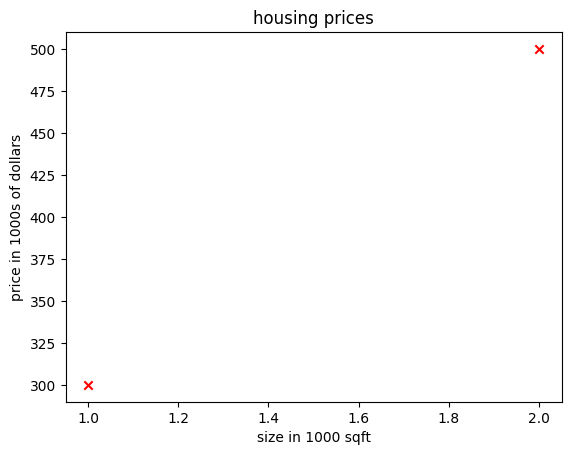

In [ ]:
plt.scatter(x_train,y_train,marker='x',c='r')
plt.title('housing prices')
plt.ylabel('price in 1000s of dollars')
plt.xlabel('size in 1000 sqft')
plt.show()

In [ ]:

def compute_model_output(x,w,b):
  m=x.shape[0]
  f_wb=np.zeros(m)
  for i in range(m):
    f_wb[i]=w*x[i]+b
  return f_wb


[300. 500.]


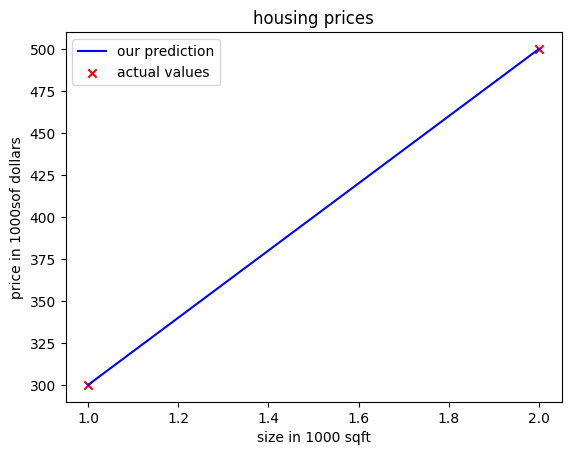

In [ ]:
w=200
b=100
tmp_f_wb = compute_model_output(x_train,w,b)
print(tmp_f_wb)
plt.plot(x_train,tmp_f_wb,c='b',label='our prediction')
plt.scatter(x_train,y_train,marker='x',c='r',label='actual values')
plt.title('housing prices')
plt.xlabel('size in 1000 sqft')
plt.ylabel('price in 1000sof dollars')
plt.legend()
plt.show()

In [ ]:
w=200
b=100
x_i=1.2 #1200 sqft house size
y_hat = w*x_i+b
print(f"${y_hat:.0f} thousand dollars")

$340 thousand dollars


In [ ]:
w = 200
b = 100
x_i = 1.2
cost_1200sqft = w * x_i + b

print(f"${cost_1200sqft:.0f} thousand dollars")

$340 thousand dollars


In [ ]:
def compute_cost(x,y,w,b):
  m=x.shape[0]
  cost_sum=0
  for i in range(m):
    f_wb = w * x[i] + b
    cost = (f_wb - y[i]) ** 2
    cost_sum +=cost
  total_cost = ( 1/ (2 * m) ) * cost_sum
  return total_cost


tmp_compute_cost=compute_cost(x_train,y_train,w,b)
print(tmp_compute_cost)



0.0


In [ ]:

b=100
w=np.array([0.0,100.0,150.0,200.0,300.0,400.0])
total_cost=np.zeros(w.shape[0])
for i in range(w.shape[0]):
  total_cost[i] = compute_cost(x_train,y_train,w[i],b)
print(total_cost)



[50000. 12500.  3125.     0. 12500. 50000.]


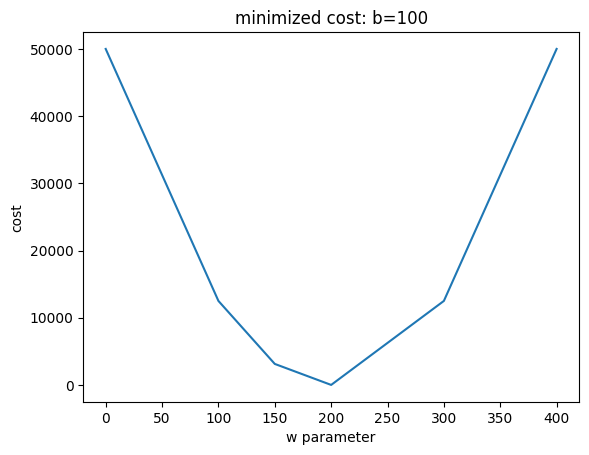

In [ ]:


plt.plot(w,total_cost)
plt.xlabel("w parameter")
plt.ylabel("cost")
plt.title("minimized cost: b=100")
plt.show()

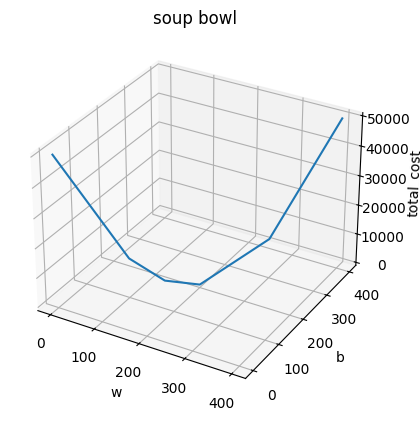

In [ ]:
b=np.array([0.0,100.0,150.0,200.0,300.0,400.0])
from mpl_toolkits.mplot3d import Axes3D
fig = plt.figure()
ax = fig.add_subplot(111, projection='3d')

# Plot the 3D line
ax.plot(w, b, total_cost)

# Add labels
ax.set_xlabel('w')
ax.set_ylabel('b')
ax.set_zlabel('total_cost')
ax.set_title('soup bowl')

plt.show()

[-650. -250.  -50.  150.  550.  950.] [-400. -150.  -25.  100.  350.  600.]


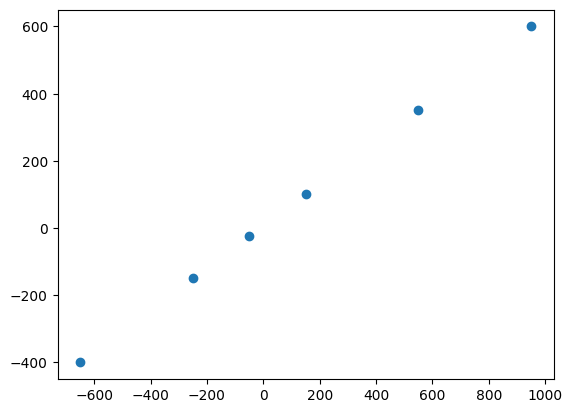

In [ ]:
def compute_gradient( x, y, w, b):
  """
    computes the gradient for linear regression
    Args:
      x (ndarray (m,0) Data m examples )
      y (ndarray (m,0) training examples )
      w,b: scalar - model parameters

    Returns:
      dj_dw = Gradient of cost function w.r.t w paramter
      dj_db = Gradient of cost function w.r.t b parameter
  """
  #training examples
  m = x.shape[0]
  dj_dw = 0
  dj_db = 0

  for i in range(m):
    dj_dw += (w*x[i] + b -y[i])*x[i]
    dj_db += w*x[i] + b -y[i]
  dj_dw /= m
  dj_db /= m

  return dj_dw, dj_db

dj_dw, dj_db = compute_gradient(x_train,y_train,w,b)
print(dj_dw, dj_db)
plt.scatter(dj_dw, dj_db)
plt.show()


In [ ]:
def gradient_descent(x, y, w_in, b_in, alpha, num_iters, cost_function, gradient_function):
  """
  Performs Gradient Desent to fit w,b.
  Updates w,b by taking num_iters gradient steps with learning rate alpha.

  Args:
    x: (ndarray (m,)): Data, m examples
    y: (ndarray (m,)): Target values
    w_in, b_in (scalar): initial values of w and b model parameters
    alpha (float): learning rate
    num_iters (int): number of iterations to run gradient desent
    cost function: function to call to produce cost
    gradient function: function to call to produce gradient

  Returns:
    w: updated value of parameter after running gradient descent
    b: updated value of parameter after running gradient descent
    J_history [list]: history of cost values
    p_history [list]: history of parameters [w,b]

  """
  w = w_in
  b = b_in
  J_history = []
  p_history = []

  for i in range(num_iters):
    #calculate the gradient and update the parameters using the gradient_function
    dj_dw, dj_db = gradient_function(x, y, w, b)
    #update the w,b parameters
    w = w - alpha * dj_dw
    b = b - alpha * dj_db
    #save cost J at each iteration
    if i<100000: #to prevent resource exhaustion
      J_history.append(cost_function(x, y, w, b))
      p_history.append([w,b])
      #print cost at every 10 intervals
      if(i % math.ceil(num_iters/10)) == 0:
        print(f"Iteration {i}: Cost {J_history[-1]} ", f"dj_dw: {dj_dw}, dj_db: {dj_db}  ", f"w: {w}, b:{b}")

  return w, b, J_history, p_history #return w and J,w history for graphing


In [ ]:
# initialize parameters
w_init = 0
b_init = 0
# some gradient descent settings
iterations = 10000
tmp_alpha = 1.0e-2
# run gradient descent
w_final, b_final, J_hist, p_hist = gradient_descent(x_train ,y_train, w_init, b_init, tmp_alpha, iterations, compute_cost, compute_gradient)
print(f"(w,b) found by gradient descent: ({w_final},{b_final})")
print(J_hist, p_hist)

Iteration 0: Cost 79274.8125  dj_dw: -650.0, dj_db: -400.0   w: 6.5, b:4.0
Iteration 1000: Cost 3.4125109319154174  dj_dw: -0.3712293911791278, dj_db: 0.6006617725498984   w: 194.91482409389593, b:108.2279874548482
Iteration 2000: Cost 0.7928950684538176  dj_dw: -0.17894237030935756, dj_db: 0.28953483718788675   w: 197.5488109193384, b:103.96610724536305
Iteration 3000: Cost 0.1842287401041018  dj_dw: -0.0862549481608994, dj_db: 0.13956343782209046   w: 198.81846212990547, b:101.91176843280807
Iteration 4000: Cost 0.04280544807338754  dj_dw: -0.041577162912062704, dj_db: 0.06727326274764778   w: 199.43046754349498, b:100.92152287232139
Iteration 5000: Cost 0.0099458226969803  dj_dw: -0.02004129053085535, dj_db: 0.032427489257486286   w: 199.72547031523698, b:100.44419836086742
Iteration 6000: Cost 0.0023109065217603642  dj_dw: -0.009660431304496342, dj_db: 0.015630906196463457   w: 199.86766944191632, b:100.21411534072959
Iteration 7000: Cost 0.0005369378798549629  dj_dw: -0.0046565830

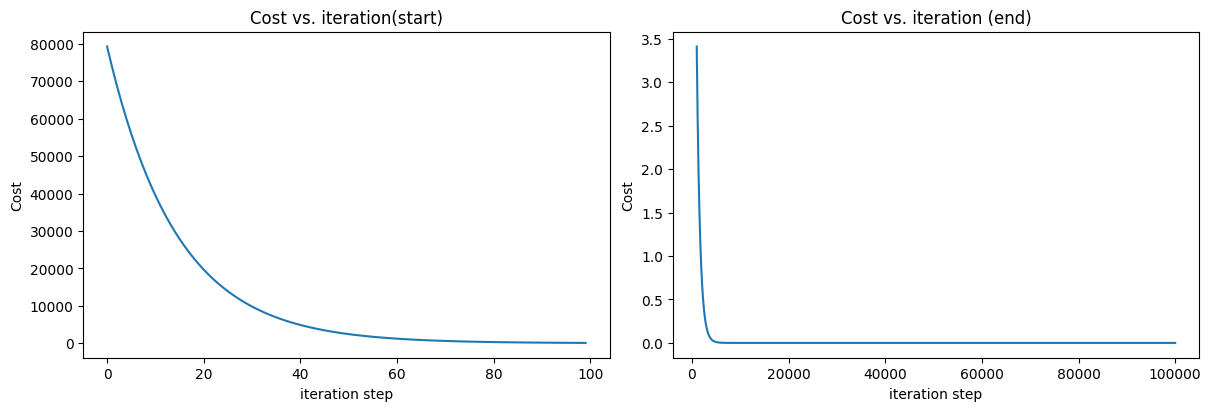

In [ ]:
# plot cost versus iteration
fig, (ax1, ax2) = plt.subplots(1, 2, constrained_layout=True, figsize=(12,4))
ax1.plot(J_hist[:100])
ax2.plot(1000 + np.arange(len(J_hist[1000:])), J_hist[1000:])
ax1.set_title("Cost vs. iteration(start)");  ax2.set_title("Cost vs. iteration (end)")
ax1.set_ylabel('Cost')            ;  ax2.set_ylabel('Cost')
ax1.set_xlabel('iteration step')  ;  ax2.set_xlabel('iteration step')
plt.show()

In [ ]:
print(f"1000 sqft house prediction {w_final*1.0 + b_final:0.1f} Thousand dollars")
print(f"1200 sqft house prediction {w_final*1.2 + b_final:0.1f} Thousand dollars")
print(f"2000 sqft house prediction {w_final*2.0 + b_final:0.1f} Thousand dollars")

1000 sqft house prediction 300.0 Thousand dollars
1200 sqft house prediction 340.0 Thousand dollars
2000 sqft house prediction 500.0 Thousand dollars


In [ ]:
# initialize parameters
w_init = 0
b_init = 0
# set alpha to a large value
iterations = 10
tmp_alpha = 8.0e-1
# run gradient descent
w_final, b_final, J_hist, p_hist = gradient_descent(x_train ,y_train, w_init, b_init, tmp_alpha, iterations, compute_cost, compute_gradient)

Iteration 0: Cost 257800.0  dj_dw: -650.0, dj_db: -400.0   w: 520.0, b:320.0
Iteration 1: Cost 781960.0  dj_dw: 1130.0, dj_db: 700.0   w: -384.0, b:-240.0
Iteration 2: Cost 2371904.3200000003  dj_dw: -1970.0, dj_db: -1216.0   w: 1192.0, b:732.8000000000001
Iteration 3: Cost 7194705.318400004  dj_dw: 3429.2000000000003, dj_db: 2120.8   w: -1551.3600000000006, b:-963.8400000000003
Iteration 4: Cost 21823770.989056017  dj_dw: -5974.160000000002, dj_db: -3690.880000000001   w: 3227.9680000000008, b:1988.864000000001
Iteration 5: Cost 66198302.85273096  dj_dw: 10403.216000000004, dj_db: 6430.8160000000025   w: -5094.604800000003, b:-3155.7888000000016
Iteration 6: Cost 200800132.73054025  dj_dw: -18120.19520000001, dj_db: -11197.696000000007   w: 9401.551360000005, b:5802.368000000004
Iteration 7: Cost 609089564.9510125  dj_dw: 31557.430400000016, dj_db: 19504.69504000001   w: -15844.392960000008, b:-9801.388032000004
Iteration 8: Cost 1847559057.6159084  dj_dw: -54963.06444800003, dj_db: -